# O6 Multimodal — no leaf/split restriction

Dimension 15, 15 instances, `min_samples_leaf=1`, and `min_samples_split=1`.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "07_no_leaf_split_seed":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o6_multi_modal/depth_policies/07_no_leaf_split_seed")
OUTPUT_DIRECTORY = HERE / "smac_output"
DIMENSION = 15
N_INSTANCES = 15
DEPTHS = (3, 6, 9, 15, 20)
FIXED = tuple(f"fixed_depth_{depth}" for depth in DEPTHS)
STAGED = "staged_depth_3_6_9_20"
ROTATING = "random_depth_3_9_20_every_50"
POLICIES = FIXED + (STAGED, ROTATING)
SEEDS = tuple(range(5))
N_TRIALS = 1200
PROBLEM_SEED = 55
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_depth_{depth}": f"depth = {depth}" for depth in DEPTHS}
LABELS.update({STAGED: "staged 3 → 6 → 9 → 20", ROTATING: "rotating {3, 9, 20} / 50"})
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4", "black", "C6")))

In [2]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        if result["smac_seed"] in SEEDS and result["n_trials"] == N_TRIALS and result["problem_seed"] == PROBLEM_SEED:
            runs[result["smac_seed"]] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing:
        raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs

results = {policy: load(policy) for policy in POLICIES}
for policy, runs in results.items():
    for result in runs.values():
        assert result["problem"] == "O6-Multimodal"
        assert result["dimension"] == DIMENSION
        assert result["n_instances"] == N_INSTANCES
        assert len(result["instance_map"]) == N_INSTANCES
        assert result["problem_seed"] == PROBLEM_SEED
        assert result["pythonhashseed"] == "12345"
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert result["min_samples_leaf"] == 1
        assert result["min_samples_split"] == 1
        assert len(result["iteration"]) == N_TRIALS
        assert len(result["best_regret"]) == N_TRIALS
        if policy in FIXED:
            assert result["max_depth"] == int(policy.rsplit("_", 1)[1])
        elif policy == STAGED:
            assert result["stage_boundaries"] == [100, 200, 500]
            assert result["depth_schedule"] == [3, 6, 9, 20]
        else:
            assert result["block_size"] == 50
            assert result["depth_choices"] == [3, 9, 20]
            assert result["policy_seed"] == 2026
print(f"Loaded {sum(map(len, results.values()))}/35 trajectories.")

Loaded 35/35 trajectories.


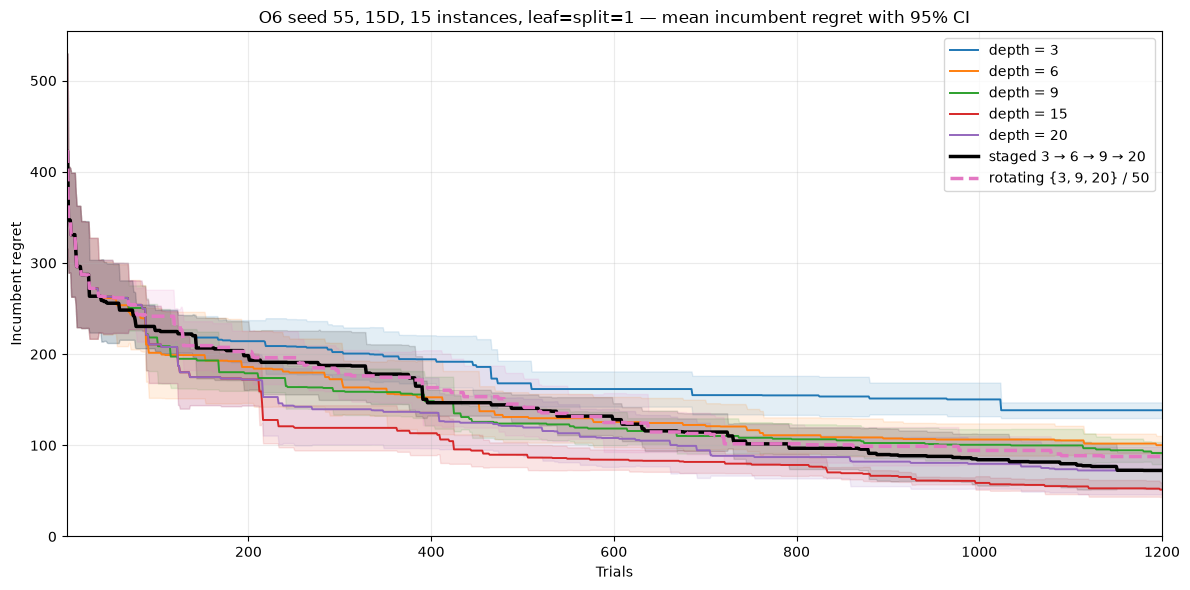

In [3]:
rows = [
    {"policy": policy, "seed": seed, "iteration": iteration, "best_regret": regret}
    for policy, runs in results.items()
    for seed, result in runs.items()
    for iteration, regret in zip(result["iteration"], result["best_regret"])
]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(12, 6))
for policy in POLICIES:
    data = summary[summary.policy == policy]
    style = "--" if policy == ROTATING else "-"
    width = 2.5 if policy in (STAGED, ROTATING) else 1.4
    ax.plot(data.iteration, data["mean"], label=LABELS[policy], color=COLORS[policy], linestyle=style, linewidth=width)
    ax.fill_between(data.iteration, np.maximum(0, data["mean"] - data.ci95), data["mean"] + data.ci95, color=COLORS[policy], alpha=.12)
ax.set(title=f"O6 seed {PROBLEM_SEED}, 15D, 15 instances, leaf=split=1 — mean incumbent regret with 95% CI", xlabel="Trials", ylabel="Incumbent regret", xlim=(1, N_TRIALS), ylim=(0, None))
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.show()

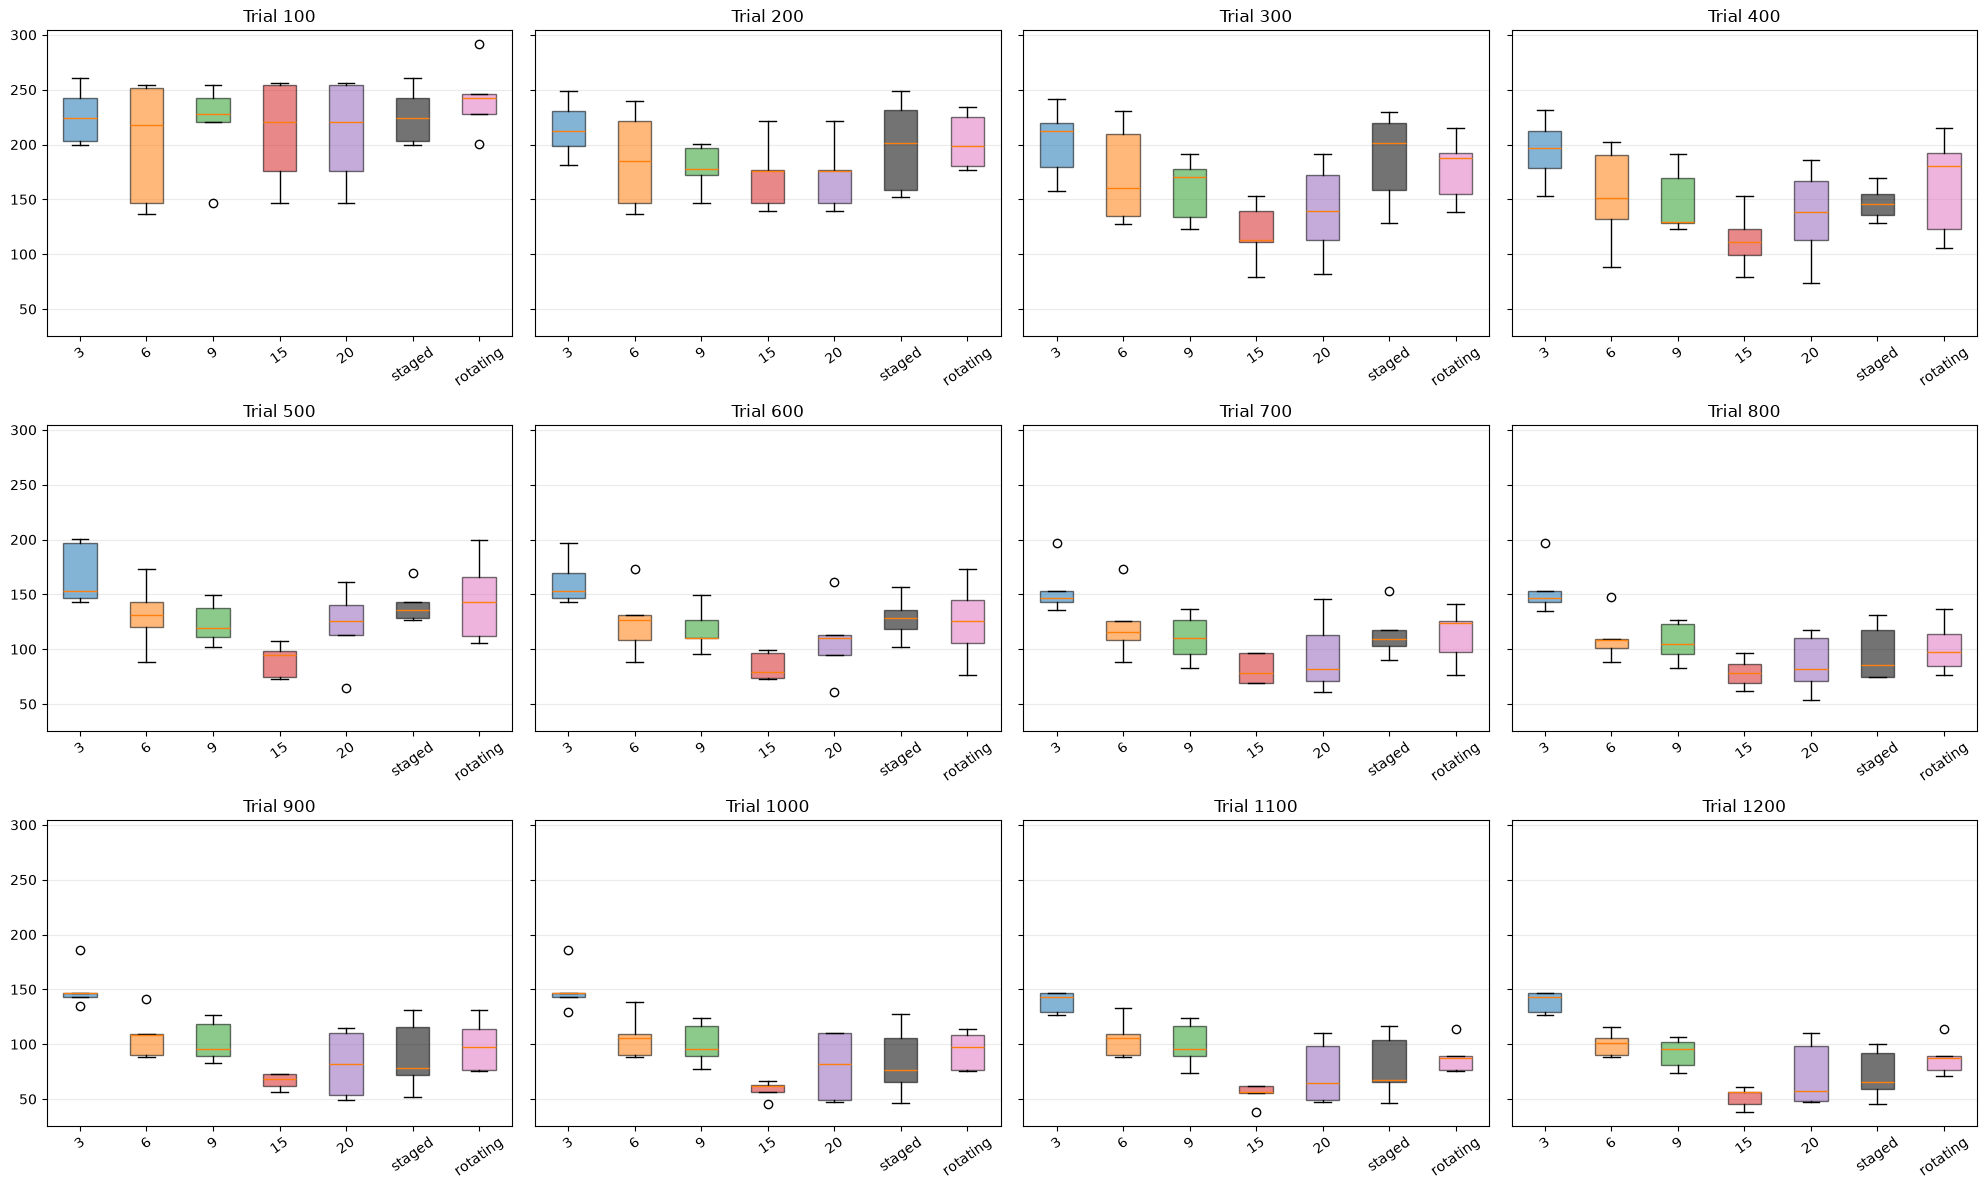

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS] for policy in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[str(depth) for depth in DEPTHS] + ["staged", "rotating"])
    for box, policy in zip(boxes["boxes"], POLICIES):
        box.set(facecolor=COLORS[policy], alpha=.55)
    ax.set_title(f"Trial {checkpoint}")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=.25)
plt.tight_layout()
plt.show()

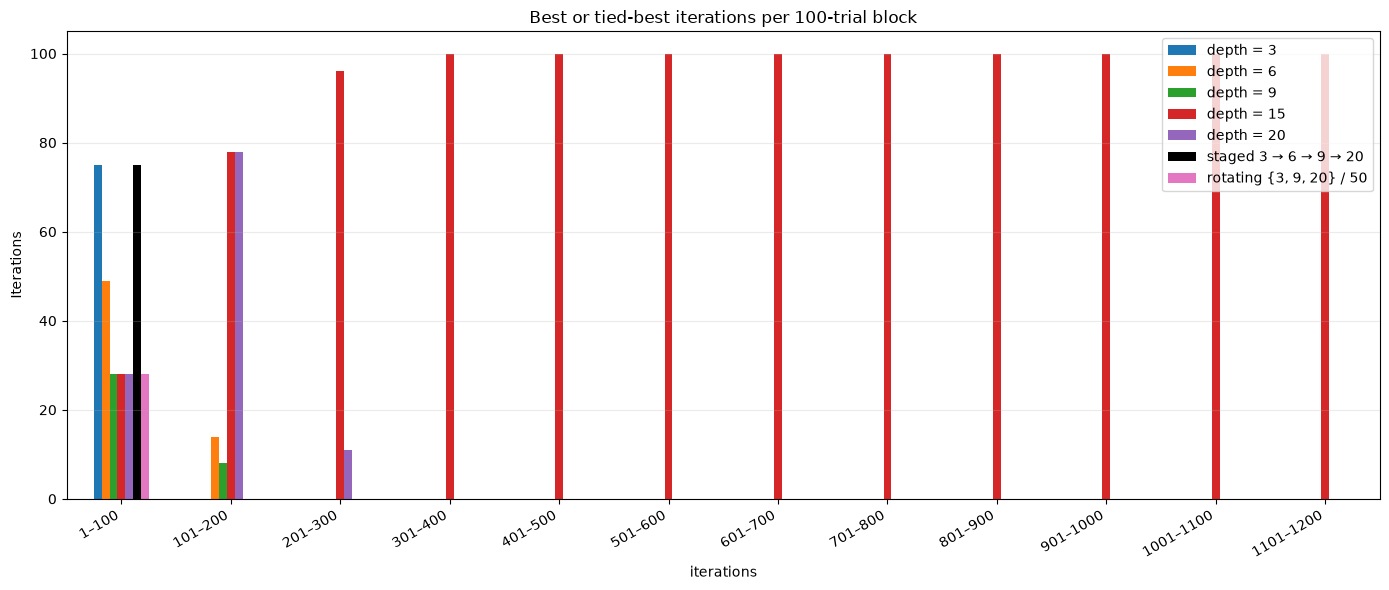

,iterations,superior policy,depth = 3,depth = 6,depth = 9,depth = 15,depth = 20,staged 3 → 6 → 9 → 20,"rotating {3, 9, 20} / 50"
0,1–100,"depth = 3, staged 3 → 6 → 9 → 20",75,49,28,28,28,75,28
1,101–200,"depth = 15, depth = 20",0,14,8,78,78,0,0
2,201–300,depth = 15,0,0,0,96,11,0,0
3,301–400,depth = 15,0,0,0,100,0,0,0
4,401–500,depth = 15,0,0,0,100,0,0,0
5,501–600,depth = 15,0,0,0,100,0,0,0
6,601–700,depth = 15,0,0,0,100,0,0,0
7,701–800,depth = 15,0,0,0,100,0,0,0
8,801–900,depth = 15,0,0,0,100,0,0,0
9,901–1000,depth = 15,0,0,0,100,0,0,0


In [5]:
mean_regret = trajectories.pivot_table(index="iteration", columns="policy", values="best_regret", aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({policy: np.isclose(mean_regret[policy], best, rtol=1e-12, atol=1e-9) for policy in POLICIES}, index=mean_regret.index)
rows = []
for end in CHECKPOINTS:
    counts = wins.loc[end - 99:end].sum()
    maximum = int(counts.max())
    row = {"iterations": f"{end - 99}–{end}", "superior policy": ", ".join(LABELS[policy] for policy in POLICIES if counts[policy] == maximum)}
    row.update({LABELS[policy]: int(counts[policy]) for policy in POLICIES})
    rows.append(row)
block_superiority = pd.DataFrame(rows)
ax = block_superiority.set_index("iterations")[[LABELS[policy] for policy in POLICIES]].plot(kind="bar", figsize=(14, 6), color=[COLORS[policy] for policy in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block", ylabel="Iterations", ylim=(0, 105))
ax.grid(axis="y", alpha=.25)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(block_superiority)

In [6]:
table = trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration", "policy"])["best_regret"].agg(["mean", "std", "min", "median", "max"])
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(table)

mean        std         min  \
iteration policy                                                            
100       fixed_depth_15                210.705096  48.292639  146.776045   
          fixed_depth_20                210.705096  48.292639  146.776045   
          fixed_depth_3                 225.951929  25.808289  199.832048   
          fixed_depth_6                 201.477006  56.389559  136.836454   
          fixed_depth_9                 218.267203  42.007209  146.776045   
          random_depth_3_9_20_every_50  241.562029  33.170928  200.149765   
          staged_depth_3_6_9_20         225.951929  25.808289  199.832048   
200       fixed_depth_15                172.192215  32.588762  139.011331   
          fixed_depth_20                172.192215  32.588762  139.011331   
          fixed_depth_3                 214.215749  26.347388  180.969291   
          fixed_depth_6                 185.919223  45.005460  136.836454   
          fixed_depth_9                 179.008452  21.740182  146.776045   
          random_depth_3_9_20_every_50  202.976048  25.950784  176.916995   
          staged_depth_3_6_9_20         198.338775  42.993833  151.885285   
300       fixed_depth_15                119.154045  28.315797   79.522610   
          fixed_depth_20                139.544260  44.122841   81.718314   
          fixed_depth_3                 202.259994  33.505847  157.384673   
          fixed_depth_6                 172.488159  45.471999  127.534304   
          fixed_depth_9                 159.406252  29.353868  123.112426   
          random_depth_3_9_20_every_50  177.653441  30.746180  138.172009   
          staged_depth_3_6_9_20         187.565943  43.147346  128.084683   
400       fixed_depth_15                113.264593  27.393421   79.522610   
          fixed_depth_20                135.590142  44.276131   73.666491   
          fixed_depth_3                 194.342232  30.055974  153.290451   
          fixed_depth_6                 152.647433  45.965751   88.208301   
          fixed_depth_9                 148.433480  30.565726  122.924781   
          random_depth_3_9_20_every_50  163.263401  46.768871  105.349624   
          staged_depth_3_6_9_20         146.729374  16.206433  128.084683   
500       fixed_depth_15                 89.663904  15.444573   72.836783   
          fixed_depth_20                121.048767  36.003009   64.976897   
          fixed_depth_3                 167.981447  28.250847  142.955173   
          fixed_depth_6                 131.082357  31.056820   88.208301   
          fixed_depth_9                 123.860227  19.479514  101.891234   
          random_depth_3_9_20_every_50  145.198807  39.000140  105.349624   
          staged_depth_3_6_9_20         140.566653  17.391666  126.705668   
600       fixed_depth_15                 84.286476  12.764819   72.836783   
          fixed_depth_20                108.037107  36.190525   60.731750   
          fixed_depth_3                 161.718517  22.012795  142.955173   
          fixed_depth_6                 125.475726  31.502666   88.208301   
          fixed_depth_9                 118.403287  20.837799   95.207859   
          random_depth_3_9_20_every_50  125.009978  36.864148   76.292815   
          staged_depth_3_6_9_20         128.108655  20.591558  101.699173   
700       fixed_depth_15                 81.788577  13.808323   68.830102   
          fixed_depth_20                 94.534501  34.558083   60.731750   
          fixed_depth_3                 155.046675  24.125463  135.859039   
          fixed_depth_6                 122.322767  31.551310   88.208301   
          fixed_depth_9                 110.265688  22.034532   82.725010   
          random_depth_3_9_20_every_50  113.003399  26.022329   76.292815   
          staged_depth_3_6_9_20         114.534862  23.501197   90.349616   
800       fixed_depth_15                 78.453446  13.755472   62.121374   
          fixed_depth_20                 8